Running Monte Carlo...

Target sparsity  : 30%
Threshold (float): 169502.70
Threshold (int)  : 169503  ← using this in the hardware register
Actual sparsity  : 30.00%
Si range         : [38837, 445173]
Si mean / std    : 196648.9 / 48181.1

Per-frame sparsity over 1000 frames:
  Mean 29.5%  Std 17.0%  Min 0.0%  Max 87.5%
  Frames with >=1 sparse row: 93.1%

Searching for a good test frame...
  Got 2 sparse rows (wanted 2)
  Si values     : [221506, 152403, 140836, 192456, 174864, 243578, 266960, 199295]
  Sparse indices: [1, 2]
  Dense indices : [0, 3, 4, 5, 6, 7]

Golden N values:
  Row 0: dense    (Si=221506)  N=[0, 9, 4, 5, 7, 15, 14, 0, 5, 5, 13, 8, 6, 4, 5, 19]
  Row 1: skipped  (Si=152403)
  Row 2: skipped  (Si=140836)
  Row 3: dense    (Si=192456)  N=[2, 7, 0, 9, 7, 16, 4, 4, 10, 0, 23, 14, 6, 4, 1, 14]
  Row 4: dense    (Si=174864)  N=[8, 5, 11, 3, 1, 1, 13, 9, 13, 6, 12, 11, 2, 2, 12, 10]
  Row 5: dense    (Si=243578)  N=[3, 8, 5, 3, 8, 4, 8, 20, 16, 4, 2, 11, 7, 6, 3, 11]
  R

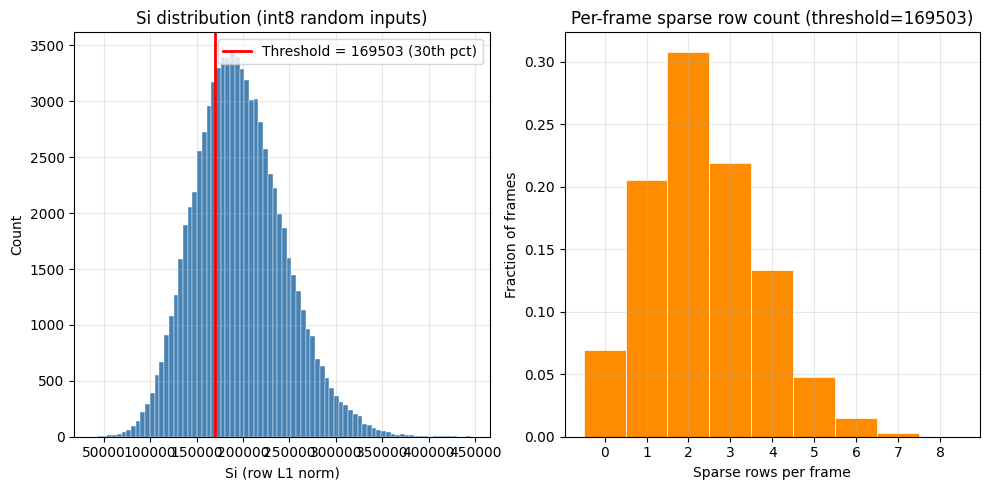


Threshold register value : 169503
Row sparsity achieved    : 30.0%
SFP cycles saved/frame   : ~21.6 / 72


In [ ]:
"""
threshold_finder.py

Find the L1-norm threshold that gives ~30% row sparsity for the QK attention workload.
Run this once to get the THRESHOLD register value to plug into the hardware.

Assumes the same parameters as core.v / fullchip.v:
  - int8 activations, 8 MAC cols, vector length 8, SFP left-shift of 7
  - 8 Q rows per frame
"""

import numpy as np
import matplotlib.pyplot as plt
import os

# match these to core.v
BW             = 8
COL            = 8
PR             = 8
SFP_SHIFT      = 7
TOTAL_CYCLE    = 8
TARGET_SPARSITY = 0.30
NUM_FRAMES     = 10000

INT8_MIN = -(2 ** (BW - 1))
INT8_MAX =  (2 ** (BW - 1)) - 1

np.random.seed(42)

# --- Monte Carlo over random frames to build up the Si distribution ---
print("Running Monte Carlo...")
all_Si = []

for frame in range(NUM_FRAMES):
    Q  = np.random.randint(INT8_MIN, INT8_MAX + 1, size=(TOTAL_CYCLE, PR))
    K  = np.random.randint(INT8_MIN, INT8_MAX + 1, size=(2 * COL, PR))
    QK = Q @ K.T
    Si = np.sum(np.abs(QK), axis=1)
    all_Si.extend(Si.tolist())

all_Si = np.array(all_Si)

# pick the threshold at the target percentile, round up to be slightly conservative
threshold_float = np.percentile(all_Si, TARGET_SPARSITY * 100)
threshold_int   = int(np.ceil(threshold_float))
actual_sparsity = np.mean(all_Si < threshold_int)

print(f"\nTarget sparsity  : {TARGET_SPARSITY*100:.0f}%")
print(f"Threshold (float): {threshold_float:.2f}")
print(f"Threshold (int)  : {threshold_int}  ← use this in the hardware register")
print(f"Actual sparsity  : {actual_sparsity*100:.2f}%")
print(f"Si range         : [{all_Si.min():.0f}, {all_Si.max():.0f}]")
print(f"Si mean / std    : {all_Si.mean():.1f} / {all_Si.std():.1f}")

# --- Check how consistent the sparsity is frame-to-frame ---
print("\nPer-frame sparsity over 1000 frames:")
frame_sparsities = []
for frame in range(1000):
    Q  = np.random.randint(INT8_MIN, INT8_MAX + 1, size=(TOTAL_CYCLE, PR))
    K  = np.random.randint(INT8_MIN, INT8_MAX + 1, size=(2 * COL, PR))
    QK = Q @ K.T
    Si = np.sum(np.abs(QK), axis=1)
    frame_sparsities.append(np.mean(Si < threshold_int))

frame_sparsities = np.array(frame_sparsities)
print(f"  Mean {frame_sparsities.mean()*100:.1f}%  Std {frame_sparsities.std()*100:.1f}%  "
      f"Min {frame_sparsities.min()*100:.1f}%  Max {frame_sparsities.max()*100:.1f}%")
print(f"  Frames with greater than 1 sparse row: {np.mean(frame_sparsities > 0)*100:.1f}%")

# --- Find a test frame with exactly the right number of sparse rows ---
print("\nSearching for a good test frame...")
target_sparse_rows = int(np.round(TARGET_SPARSITY * TOTAL_CYCLE))

best_Q, best_K, best_QK, best_Si = None, None, None, None
best_diff = 9999

for _ in range(100000):
    Q  = np.random.randint(INT8_MIN, INT8_MAX + 1, size=(TOTAL_CYCLE, PR))
    K  = np.random.randint(INT8_MIN, INT8_MAX + 1, size=(2 * COL, PR))
    QK = Q @ K.T
    Si = np.sum(np.abs(QK), axis=1)
    diff = abs(int(np.sum(Si < threshold_int)) - target_sparse_rows)
    if diff < best_diff:
        best_diff = diff
        best_Q, best_K, best_QK, best_Si = Q.copy(), K.copy(), QK.copy(), Si.copy()
    if best_diff == 0:
        break

sparse_rows = np.where(best_Si < threshold_int)[0]
dense_rows  = np.where(best_Si >= threshold_int)[0]
print(f"  Got {len(sparse_rows)} sparse rows (wanted {target_sparse_rows})")
print(f"  Si values     : {best_Si.tolist()}")
print(f"  Sparse indices: {sparse_rows.tolist()}")
print(f"  Dense indices : {dense_rows.tolist()}")

# --- Compute golden N values for the test frame ---
# sparse rows get N=0 (hardware skips them), dense rows use the SFP formula
print("\nGolden N values:")
N_golden = np.zeros((TOTAL_CYCLE, 2 * COL), dtype=int)

for t in range(TOTAL_CYCLE):
    if best_Si[t] < threshold_int:
        print(f"  Row {t}: skipped  (Si={best_Si[t]:.0f})")
    else:
        denom = int(best_Si[t])
        for j in range(2 * COL):
            N_golden[t][j] = (int(abs(best_QK[t][j])) << SFP_SHIFT) // denom
        print(f"  Row {t}: dense    (Si={best_Si[t]:.0f})  N={N_golden[t].tolist()}")

# --- Write pattern files for the testbench ---
os.makedirs("sim/pattern", exist_ok=True)

with open("sim/pattern/qdata_sparse.txt", "w") as f:
    for t in range(TOTAL_CYCLE):
        for k in range(PR):
            f.write(f"{int(best_Q[t][k])}\n")

with open("sim/pattern/kdata_dual_sparse.txt", "w") as f:
    for j in range(2 * COL):
        for k in range(PR):
            f.write(f"{int(best_K[j][k])}\n")

with open("sim/pattern/threshold.txt", "w") as f:
    f.write(f"{threshold_int}\n")

with open("sim/pattern/golden_N_sparse.txt", "w") as f:
    for t in range(TOTAL_CYCLE):
        for j in range(2 * COL):
            f.write(f"{N_golden[t][j]}\n")

print("\nWrote sim/pattern/{qdata,kdata_dual,threshold,golden_N}_sparse.txt")

# --- Plots ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(all_Si, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
plt.axvline(threshold_int, color='red', linewidth=2,
            label=f'Threshold = {threshold_int} ({TARGET_SPARSITY*100:.0f}th pct)')
plt.xlabel('Si (row L1 norm)')
plt.ylabel('Count')
plt.title('Si distribution (int8 random inputs)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
bins = np.arange(0, TOTAL_CYCLE + 2) - 0.5
plt.hist(np.round(frame_sparsities * TOTAL_CYCLE).astype(int),
         bins=bins, color='darkorange', edgecolor='white', linewidth=0.5, density=True)
plt.xlabel('Sparse rows per frame')
plt.ylabel('Fraction of frames')
plt.title(f'Per-frame sparse row count (threshold={threshold_int})')
plt.xticks(range(TOTAL_CYCLE + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150)
plt.show()

print(f"\nThreshold register value : {threshold_int}")
print(f"Row sparsity achieved    : {actual_sparsity*100:.1f}%")
print(f"SFP cycles saved/frame   : ~{actual_sparsity * TOTAL_CYCLE * 9:.1f} / {TOTAL_CYCLE * 9}")